# 3. Backpropagation

Where we left off: we could *build* a two-layer network, but we could not
*train* one, because we had no way to get the slope of the loss with respect
to a weight buried in the hidden layer. Now we apply chain rule to fix this.

In [7]:
# --- setup: run me first ------------------------------------------------
import sys, os, urllib.request

sys.path.append("..")          # if you cloned the repo, the helper is one level up
if not os.path.exists("workshop_utils.py") and "workshop_utils" not in sys.modules:
    try:
        import workshop_utils
    except ImportError:        # we are on Colab: fetch the helper
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/ShrRa/vistula_workshop/main/workshop_utils.py",
            "workshop_utils.py")

import numpy as np
import matplotlib.pyplot as plt
import workshop_utils as wu

np.random.seed(0)   # so that everyone in the room sees the same plots
plt.rcParams["figure.figsize"] = (5, 4)

## 1. The chain rule

Take $f(x) = (3x + 1)^2$ and split it into two steps:

$$u = 3x + 1 \qquad f = u^2$$

*Rhe chain rule:* if $x$ affects $u$, and $u$ affects $f$, then the
effect of $x$ on $f$ is the **product** of the two:

$$\frac{df}{dx} = \frac{df}{du}\cdot\frac{du}{dx} = 2u \cdot 3$$

In words: "nudging $x$ by a little moves $u$ 3 times as much, and each unit of
$u$ moves $f$ by $2u$." Sensitivities multiply along the chain.

In [1]:
def f(x):
    return (3 * x + 1) ** 2

In [2]:

x = 2.0

# forward: compute, and keep the intermediate value
u = 3 * x + 1
out = u ** 2
print(f"forward : x = {x} -> u = {u} -> f = {out}")

forward : x = 2.0 -> u = 7.0 -> f = 49.0


In [3]:
# backward: walk back along the chain, multiplying sensitivities
df_du = 2 * u          # how f responds to u
du_dx = 3              # how u responds to x
df_dx = df_du * du_dx  # how f responds to x
print(f"backward: df/du = {df_du}, du/dx = {du_dx}  ->  df/dx = {df_dx}")

print("measured :", (f(x + 1e-5) - f(x - 1e-5)) / 2e-5)

backward: df/du = 14.0, du/dx = 3  ->  df/dx = 42.0
measured : 42.000000000896875


* Rhe forward pass produced an intermediate, `u`, and we **kept** it;
* the backward pass needed `u` (in `2 * u`) and ran in the opposite order;
* each step was a multiplication by a local sensitivity.

## 2. A forward pass that remembers

Same 2-2-1 code as notebook 2, but now we return the intermediates as well,
because the backward pass will need them.

This is why training a model costs far more memory than running one: inference
can throw `z1, a1` away immediately, training cannot.

In [39]:
def sigmoid(z):
    return np.max(0, z)   #ReLU
    #return 1 / (1 + np.exp(-z))


def forward(X, W1, b1, W2, b2):
    z1 = X  @ W1 + b1      # (N, H)  hidden pre-activations
    a1 = sigmoid(z1)       # (N, H)  hidden outputs
    z2 = a1 @ W2 + b2      # (N, 1)  output pre-activation
    a2 = sigmoid(z2)       # (N, 1)  the prediction
    return z1, a1, z2, a2


def bce(a2, y):
    a2 = np.clip(a2, 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(a2) + (1 - y) * np.log(1 - a2))

## 3. The backward pass

We want four gradients: `dW1, db1, dW2, db2`. We get them by walking backwards
from the loss, carrying one quantity per layer -- conventionally called
**delta**, the sensitivity of the loss to that layer's pre-activation `z`.

**Output layer.** For cross-entropy, loss and a sigmoid output terms cancel and the sensitivity is just the
error itself.

$$\delta_2 = \frac{a_2 - y}{N}$$

**Hidden layer.**  The hidden
neuron affected the loss only through the output neuron, so take the output's
delta, send it back through the weights that carried it forward ($W_2^T$),
and multiply by the local slope of the sigmoid:

$$\delta_1 = \left(\delta_2\, W_2^{T}\right) \odot \sigma'(z_1),
\qquad \sigma'(z) = \sigma(z)\,(1 - \sigma(z)) = a\,(1-a)$$

Then, for either layer, the gradient of its weights is `(what came in)^T @ (delta)`.

In [40]:
def backward(X, y, z1, a1, z2, a2, W2):
    """All four gradients, in one pass backwards through the network."""
    N = X.shape[0]

    # --- output layer ---
    d2 = (a2 - y) / N                    # (N, 1)
    dW2 = a1.T @ d2                      # (H, 1)
    db2 = d2.sum(axis=0)                 # (1,)

    # --- hidden layer: send the blame back through W2 ---
    d1 = (d2 @ W2.T) * a1 * (1 - a1)
    dW1 = X.T @ d1                       # (2, H)
    db1 = d1.sum(axis=0)                 # (H,)

    return dW1, db1, dW2, db2

## 4. Manual checks

Wiggle one weight, see how the loss responds, and compare with what
backprop claims. 

In [41]:
np.random.seed(1)
Xc = np.random.randn(5, 2)
yc = np.array([[0.], [1.], [1.], [0.], [1.]])
W1c, b1c = np.random.randn(2, 3), np.zeros(3)
W2c, b2c = np.random.randn(3, 1), np.zeros(1)

# what backprop says
dW1c, _, _, _ = backward(Xc, yc, *forward(Xc, W1c, b1c, W2c, b2c), W2c)

# what the wiggle test says
h = 1e-6
dW1_numeric = np.zeros_like(W1c)
for i in range(W1c.shape[0]):
    for j in range(W1c.shape[1]):
        up, down = W1c.copy(), W1c.copy()
        up[i, j] += h; down[i, j] -= h
        loss_up   = bce(forward(Xc, up,   b1c, W2c, b2c)[3], yc)
        loss_down = bce(forward(Xc, down, b1c, W2c, b2c)[3], yc)
        dW1_numeric[i, j] = (loss_up - loss_down) / (2 * h)

print("backprop says:\n", dW1c.round(8))
print("\nwiggling says:\n", dW1_numeric.round(8))
print("\nlargest disagreement:", np.abs(dW1c - dW1_numeric).max())

TypeError: only integer scalar arrays can be converted to a scalar index

Agreement to roughly eight decimals. The remaining difference is floating-point
noise in the wiggle test, not an error in backprop.

## 5. Training a real network

Two half-circles that interlock. No line can separate them, and unlike XOR
there is no way OR and AND can solve it.

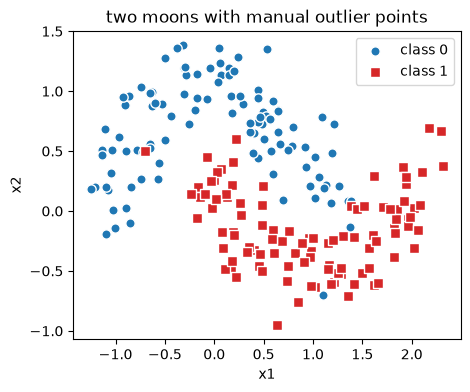

In [27]:
def make_moons(n=200, noise=0.2):
    t = np.linspace(0, np.pi, n // 2)
    outer = np.c_[np.cos(t), np.sin(t)]
    inner = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    X = np.vstack([outer, inner]) + np.random.normal(0, noise, (n, 2))
    y = np.hstack([np.zeros(n // 2), np.ones(n // 2)]).reshape(-1, 1)
    
    # Add manual outlier/noise points
    extra_X = np.array([
        [0.5, 0.6],
        [0.2, -0.2],
        [0.8, 0.7],
        [-0.7, 0.5],
        [1.1, -0.7]
    ])
    extra_y = np.array([[0], [1], [0], [1], [0]])
    
    X = np.vstack([X, extra_X])
    y = np.vstack([y, extra_y])
    return X, y


np.random.seed(0)
X, y = make_moons()
wu.plot_points(X, y); plt.legend(); plt.title("two moons with manual outlier points"); plt.show()

The training loop. Read it and notice how little of it is new: lines 1-3 are
notebook 1's `x = x - lr * grad`, repeated four times because we now have four
parameter arrays instead of one number.

One new detail: the weights start **random, not zero**. If every hidden neuron
started identical, they would receive identical gradients and stay identical
forever -- an expensive way to have one neuron. Random initialisation breaks
that symmetry. (There is a demo of this in the take-home section.)

In [34]:
H = 5                     # hidden neurons
lr = 0.5
n_epochs = 4000

np.random.seed(2)
W1 = np.random.randn(2, H) * 0.5;  b1 = np.zeros(H)
W2 = np.random.randn(H, 1) * 0.5;  b2 = np.zeros(1)

history, snapshots = [], []
for epoch in range(n_epochs + 1):
    z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
    history.append(bce(a2, y))

    dW1, db1, dW2, db2 = backward(X, y, z1, a1, z2, a2, W2)
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    if epoch in (0, 100, 500, 1000, 2000, n_epochs):
        snapshots.append((epoch, W1.copy(), b1.copy(), W2.copy(), b2.copy()))

accuracy = np.mean((a2 > 0.5) == y)
print(f"loss {history[0]:.3f} -> {history[-1]:.3f},  accuracy {accuracy:.1%}")

loss 0.788 -> 0.133,  accuracy 97.1%


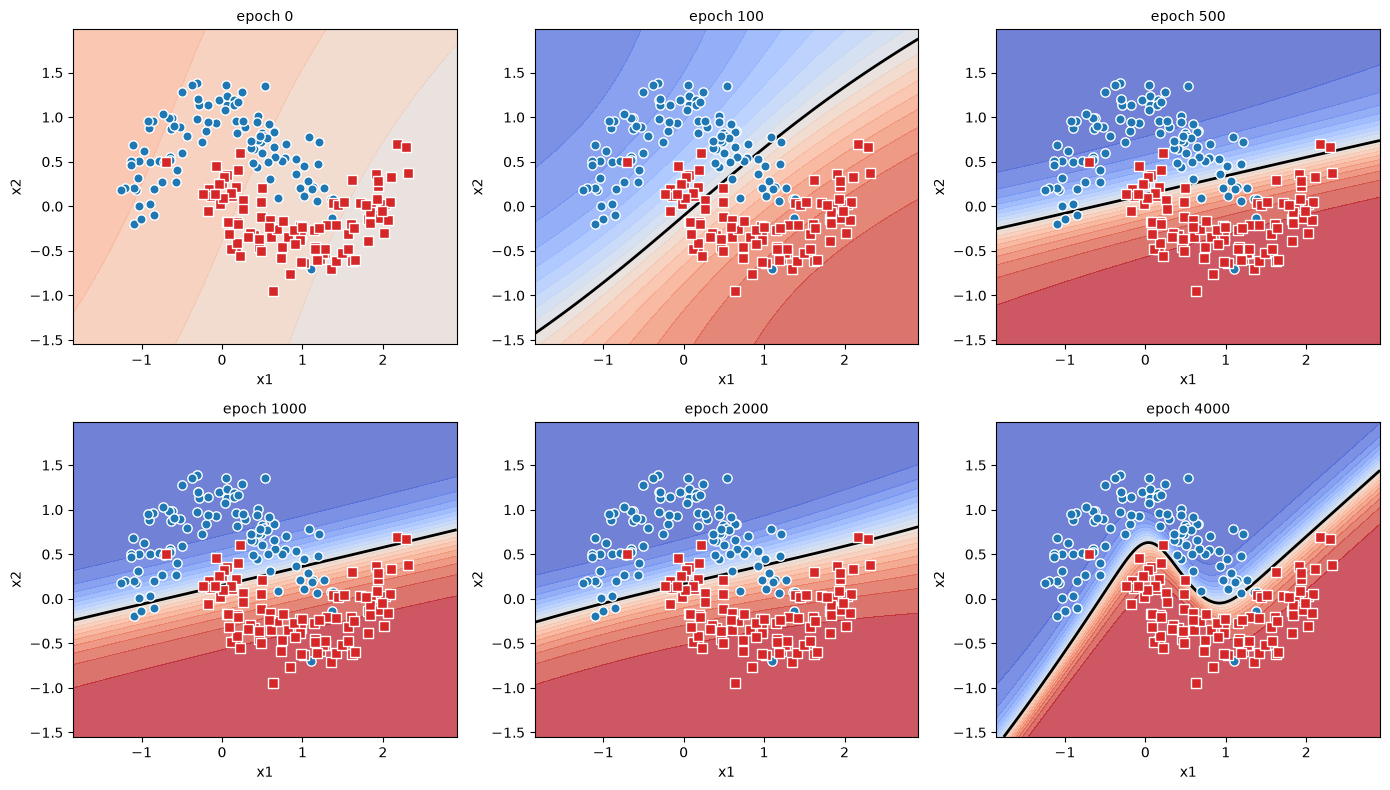

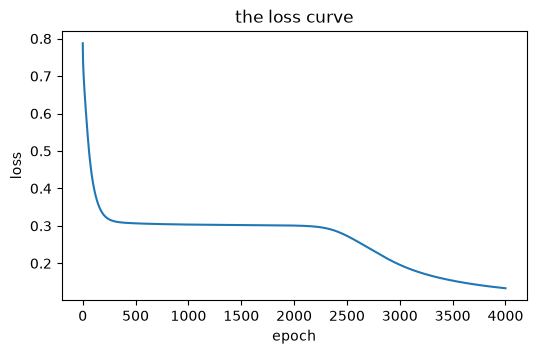

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (epoch, w1, bb1, w2, bb2) in zip(axes.ravel(), snapshots):
    wu.plot_boundary(lambda G: forward(G, w1, bb1, w2, bb2)[3].ravel(),
                     X, y, ax=ax, title=f"epoch {epoch}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(history); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("the loss curve"); plt.show()

We specified the
*architecture* (8 hidden neurons) and the *objective* (cross-entropy), and the
shape was found by repeatedly measuring a slope and stepping downhill.

Notice the boundary is still built from straight cuts -- eight of them, one per
hidden neuron, blended by the sigmoid. Zoom in on the far edges of the plot and
you can see them individually. Stack more layers and the cuts compose into
arbitrarily complicated shapes. 